In [1]:
"""
01_eda.ipynb — Exploratory Data Analysis
Acinetobacter baumannii AMR Dataset (BV-BRC)

Purpose: Understand the structure, distributions, and biological
patterns in our dataset before building any predictive model.

Author: Menzi
Date:   2026-06-17
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid", font_scale=1.2)
PALETTE = sns.color_palette("colorblind")
FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)
DPI = 300

print("Libraries loaded.")
print(f"Figures will be saved to: {FIG_DIR}")

Libraries loaded.
Figures will be saved to: ../outputs/figures


In [2]:
# Load the raw TSV file
df = pd.read_csv("../data/raw/acinetobacter_baumannii_amr_raw.tsv", sep="\t")
# check shape and dtypes
print("Shape:", df.shape)
print()
print("Column data types:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()

Shape: (21331, 10)

Column data types:
antibiotic                   object
measurement_value            object
resistant_phenotype          object
evidence                     object
genome_id                   float64
genome_name                  object
laboratory_typing_method     object
taxon_id                      int64
measurement_sign             object
measurement_unit             object
dtype: object

First 5 rows:


,antibiotic,measurement_value,resistant_phenotype,evidence,genome_id,genome_name,laboratory_typing_method,taxon_id,measurement_sign,measurement_unit
0,chloramphenicol,NaN,Resistant,Laboratory Method,470.22928,Acinetobacter baumannii 20200317_MGL_38,Disk diffusion,470,NaN,NaN
1,ticarcillin/clavulanic acid,NaN,Resistant,Laboratory Method,470.17520,Acinetobacter baumannii strain A388,Disk diffusion,470,NaN,NaN
2,ceftriaxone,NaN,Resistant,Laboratory Method,470.16315,Acinetobacter baumannii 165_an,Disk diffusion,470,NaN,NaN
3,levofloxacin,4,Resistant,Laboratory Method,470.74440,Acinetobacter baumannii strain MRSN11714,Broth dilution,470,>,mg/L
4,cefazolin,64,Resistant,Laboratory Method,470.80270,Acinetobacter baumannii strain MRSN7740,Broth dilution,470,>=,mg/L


In [3]:
print("Columns stored as text (object dtype):")
text_cols = df.select_dtypes(include="object").columns.tolist()
for col in text_cols:
    n_unique = df[col].nunique()
    print(f"  {col}: {n_unique} unique values")

print()
print("Columns stored as numbers:")
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
for col in num_cols:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}")

Columns stored as text (object dtype):
  antibiotic: 55 unique values
  measurement_value: 55 unique values
  resistant_phenotype: 2 unique values
  evidence: 1 unique values
  genome_name: 1403 unique values
  laboratory_typing_method: 3 unique values
  measurement_sign: 4 unique values
  measurement_unit: 2 unique values

Columns stored as numbers:
  genome_id: min=470.11118, max=470.8401
  taxon_id: min=470, max=470


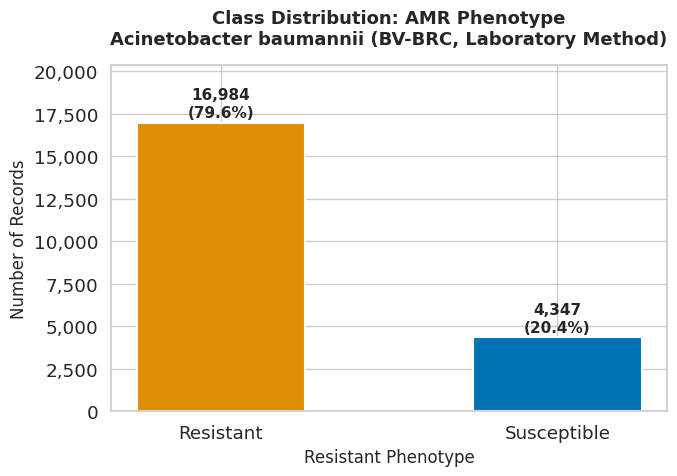

Figure saved: 01_class_distribution.png


In [4]:
# Figure 1: Class Distribution
fig, ax = plt.subplots(figsize=(7, 5))
class_counts = df["resistant_phenotype"].value_counts()

# Create bar plot
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=[PALETTE[1], PALETTE[0]],  # orange for Resistant, blue for Susceptible
    edgecolor="white",
    linewidth=1.5,
    width=0.5,
)

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position: centre of bar
        bar.get_height() + 150,              # y position: just above bar
        f"{count:,}\n({count/len(df)*100:.1f}%)",  # text: count and percentage
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# Labels and formatting
ax.set_title(
    "Class Distribution: AMR Phenotype\nAcinetobacter baumannii (BV-BRC, Laboratory Method)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Resistant Phenotype", fontsize=12)
ax.set_ylabel("Number of Records", fontsize=12)
ax.set_ylim(0, class_counts.max() * 1.2)  # 20% headroom above tallest bar
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_class_distribution.png"), dpi=DPI, bbox_inches="tight")
plt.show()
print("Figure saved: 01_class_distribution.png")

In [5]:
# Figure 2: Resistance Rate per Antibiotic

MIN_RECORDS = 100

# groupby() splits the DataFrame by antibiotic, then we compute stats per group
antibiotic_stats = (
    df.groupby("antibiotic")
    .agg(
        total=("resistant_phenotype", "count"),
        resistant=("resistant_phenotype", lambda x: (x == "Resistant").sum())
    )
    .assign(resistance_rate=lambda x: x["resistant"] / x["total"] * 100)
    .query(f"total >= {MIN_RECORDS}")
    .sort_values("resistance_rate", ascending=True)
    .reset_index()
)

print(f"Antibiotics with ≥{MIN_RECORDS} records: {len(antibiotic_stats)}")
print(antibiotic_stats[["antibiotic", "total", "resistant", "resistance_rate"]].to_string())

Antibiotics with ≥100 records: 28
                       antibiotic  total  resistant  resistance_rate
0                     tigecycline    196          2         1.020408
1                        colistin    260         11         4.230769
2                     polymyxin B    104         17        16.346154
3                     minocycline    112         23        20.535714
4                       doripenem    177         46        25.988701
5                        imipenem   1314        653        49.695586
6            ampicillin/sulbactam    995        533        53.567839
7                        amikacin   1358        792        58.321060
8                      tobramycin   1296        841        64.891975
9                     doxycycline    148         97        65.540541
10                      meropenem    553        375        67.811935
11                   tetracycline    939        727        77.422790
12                   levofloxacin   1034        847        81.914894


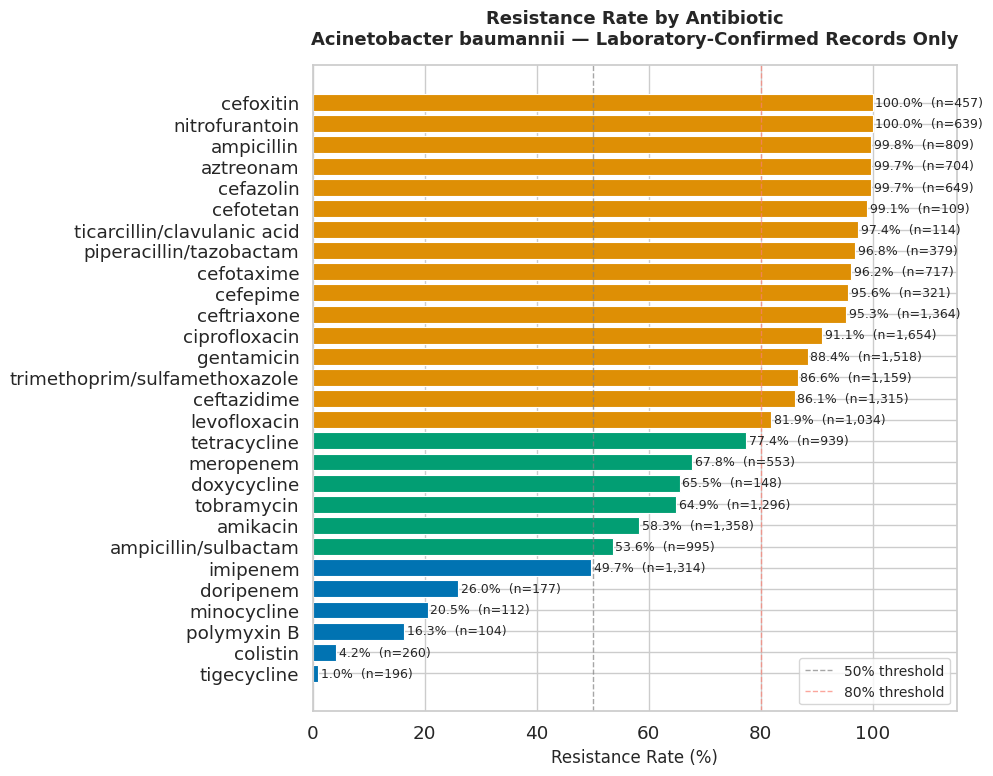

Figure saved: 02_resistance_rate_by_antibiotic.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colour bars by resistance rate
# High resistance (>80%) → red-orange tones
# Low resistance (<50%)  → blue-green tones
colors = [
    PALETTE[1] if rate >= 80
    else PALETTE[2] if rate >= 50
    else PALETTE[0]
    for rate in antibiotic_stats["resistance_rate"]
]

bars = ax.barh(
    antibiotic_stats["antibiotic"],
    antibiotic_stats["resistance_rate"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)

# Add rate labels at end of each bar
for bar, rate, total in zip(
    bars,
    antibiotic_stats["resistance_rate"],
    antibiotic_stats["total"]
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  (n={total:,})",
        va="center",
        fontsize=9,
    )

# Reference line at 50%
ax.axvline(50, color="grey", linestyle="--", linewidth=1, alpha=0.7, label="50% threshold")
ax.axvline(80, color="salmon", linestyle="--", linewidth=1, alpha=0.7, label="80% threshold")

ax.set_xlim(0, 115)
ax.set_xlabel("Resistance Rate (%)", fontsize=12)
ax.set_title(
    "Resistance Rate by Antibiotic\nAcinetobacter baumannii — Laboratory-Confirmed Records Only",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_resistance_rate_by_antibiotic.png"), dpi=DPI, bbox_inches="tight")
plt.show()
print("Figure saved: 02_resistance_rate_by_antibiotic.png")

In [7]:
# Figure 3: Aminoglycoside Spotlight
# Aminoglycosides in this dataset:
AMINOGLYCOSIDES = [
    "amikacin",
    "gentamicin",
    "tobramycin",
    "streptomycin",
    "kanamycin",
    "netilmicin",
]

# Filter to aminoglycosides only
df_amino = df[df["antibiotic"].isin(AMINOGLYCOSIDES)].copy()

print("Aminoglycoside records found:")
print(df_amino["antibiotic"].value_counts().to_string())
print(f"\nTotal aminoglycoside records: {len(df_amino):,}")
print(f"Proportion of full dataset: {len(df_amino)/len(df)*100:.1f}%")

# Resistance rate per aminoglycoside
amino_stats = (
    df_amino.groupby("antibiotic")
    .agg(
        total=("resistant_phenotype", "count"),
        resistant=("resistant_phenotype", lambda x: (x == "Resistant").sum())
    )
    .assign(resistance_rate=lambda x: x["resistant"] / x["total"] * 100)
    .sort_values("resistance_rate", ascending=False)
    .reset_index()
)

print("\nAminoglycoside resistance rates:")
print(amino_stats.to_string(index=False))

Aminoglycoside records found:
antibiotic
gentamicin      1518
amikacin        1358
tobramycin      1296
kanamycin         75
streptomycin      67
netilmicin         1

Total aminoglycoside records: 4,315
Proportion of full dataset: 20.2%

Aminoglycoside resistance rates:
  antibiotic  total  resistant  resistance_rate
   kanamycin     75         75       100.000000
  netilmicin      1          1       100.000000
streptomycin     67         67       100.000000
  gentamicin   1518       1342        88.405797
  tobramycin   1296        841        64.891975
    amikacin   1358        792        58.321060


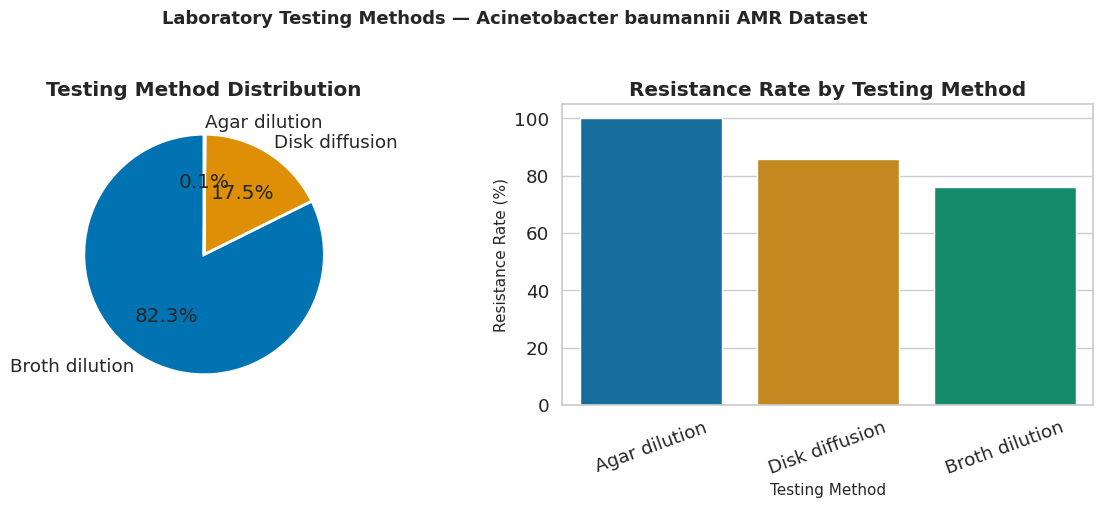

Figure saved: 03_testing_method_analysis.png


In [9]:
# Figure 4: Testing Method Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: testing method counts
method_counts = df["laboratory_typing_method"].value_counts()
axes[0].pie(
    method_counts.values,
    labels=method_counts.index,
    autopct="%1.1f%%",
    colors=PALETTE[:len(method_counts)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Testing Method Distribution", fontweight="bold")

# Right plot: resistance rate by testing method
method_resist = (
    df.groupby("laboratory_typing_method")
    .agg(
        total=("resistant_phenotype", "count"),
        resistant=("resistant_phenotype", lambda x: (x == "Resistant").sum())
    )
    .assign(rate=lambda x: x["resistant"] / x["total"] * 100)
    .query("total >= 20")
    .sort_values("rate", ascending=False)
    .reset_index()
)

sns.barplot(
    data=method_resist,
    x="laboratory_typing_method",
    y="rate",
    hue="laboratory_typing_method",
    palette=PALETTE[:len(method_resist)],
    legend=False,
    ax=axes[1],
)

axes[1].set_xlabel("Testing Method", fontsize=11)
axes[1].set_ylabel("Resistance Rate (%)", fontsize=11)
axes[1].set_title("Resistance Rate by Testing Method", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle(
    "Laboratory Testing Methods — Acinetobacter baumannii AMR Dataset",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_testing_method_analysis.png"), dpi=DPI, bbox_inches="tight")
plt.show()
print("Figure saved: 03_testing_method_analysis.png")

In [10]:
# Cell 9: Define modelling subset
MODEL_ANTIBIOTICS = ["amikacin", "gentamicin", "tobramycin"]

df_model = df[df["antibiotic"].isin(MODEL_ANTIBIOTICS)].copy()

print("=" * 50)
print("MODELLING DATASET SUMMARY")
print("=" * 50)
print(f"\nAntibiotics included: {MODEL_ANTIBIOTICS}")
print(f"Total records       : {len(df_model):,}")
print()
print("Records per antibiotic:")
print(df_model["antibiotic"].value_counts().to_string())
print()
print("Resistance distribution per antibiotic:")
pivot = df_model.groupby(["antibiotic", "resistant_phenotype"]).size().unstack(fill_value=0)
pivot["resistance_rate_%"] = (pivot["Resistant"] / pivot.sum(axis=1) * 100).round(1)
print(pivot.to_string())
print()
print("Testing methods in modelling subset:")
print(df_model["laboratory_typing_method"].value_counts().to_string())
print()
print("Missing values in modelling subset:")
print(df_model.isnull().sum().to_string())

MODELLING DATASET SUMMARY

Antibiotics included: ['amikacin', 'gentamicin', 'tobramycin']
Total records       : 4,172

Records per antibiotic:
antibiotic
gentamicin    1518
amikacin      1358
tobramycin    1296

Resistance distribution per antibiotic:
resistant_phenotype  Resistant  Susceptible  resistance_rate_%
antibiotic                                                    
amikacin                   792          566               58.3
gentamicin                1342          176               88.4
tobramycin                 841          455               64.9

Testing methods in modelling subset:
laboratory_typing_method
Broth dilution    3083
Disk diffusion     521

Missing values in modelling subset:
antibiotic                    0
measurement_value           858
resistant_phenotype           0
evidence                      0
genome_id                     0
genome_name                   0
laboratory_typing_method    568
taxon_id                      0
measurement_sign            930